<a href="https://colab.research.google.com/github/Prakruthir12/Streaming-Content-Dataset-Analysis/blob/main/Netflix_BusinessCase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/SCALER/netflix_dataset.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.shape

(8807, 12)

In [ ]:
df['title'].nunique()

8807

In [ ]:
df.isnull().sum()*100/len(df)

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


**Split Nested Columns**

In [ ]:
cast_split = df['cast'].str.split(',', expand=True)
df_cast = pd.concat([df['title'], cast_split], axis=1)
df_cast

,title,0,1,2,3,4,5,6,7,8,...,40,41,42,43,44,45,46,47,48,49
0,Dick Johnson Is Dead,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jailbirds New Orleans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,...,None,None,None,None,None,None,None,None,None,None
8803,Zombie Dumb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,None
8804,Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,...,None,None,None,None,None,None,None,None,None,None
8805,Zoom,Tim Allen,Courteney Cox,Chevy Chase,Kate Mara,Ryan Newman,Michael Cassidy,Spencer Breslin,Rip Torn,Kevin Zegers,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
df_cast_stack = df_cast.set_index('title').stack().reset_index(level=1, drop=True).reset_index(name='cast')
df_cast_stack

,title,cast
0,Blood & Water,Ama Qamata
1,Blood & Water,Khosi Ngema
2,Blood & Water,Gail Mabalane
3,Blood & Water,Thabang Molaba
4,Blood & Water,Dillon Windvogel
...,...,...
64121,Zubaan,Manish Chaudhary
64122,Zubaan,Meghna Malik
64123,Zubaan,Malkeet Rauni
64124,Zubaan,Anita Shabdish


In [ ]:
country_split = df['country'].str.split(',', expand=True)
country_split.columns = ['country_' + str(col) for col in country_split.columns]

In [ ]:
df_country = pd.concat([df['title'], country_split], axis=1)
df_country

,title,country_0,country_1,country_2,country_3,country_4,country_5,country_6,country_7,country_8,country_9,country_10,country_11
0,Dick Johnson Is Dead,United States,None,None,None,None,None,None,None,None,None,None,None
1,Blood & Water,South Africa,None,None,None,None,None,None,None,None,None,None,None
2,Ganglands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jailbirds New Orleans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kota Factory,India,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,Zodiac,United States,None,None,None,None,None,None,None,None,None,None,None
8803,Zombie Dumb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8804,Zombieland,United States,None,None,None,None,None,None,None,None,None,None,None
8805,Zoom,United States,None,None,None,None,None,None,None,None,None,None,None


In [ ]:
df_country_stack = df_country.set_index('title').stack().reset_index(level=1, drop=True).reset_index(name='country')
df_country_stack

,title,country
0,Dick Johnson Is Dead,United States
1,Blood & Water,South Africa
2,Kota Factory,India
3,Sankofa,United States
4,Sankofa,Ghana
...,...,...
10014,Zinzana,Jordan
10015,Zodiac,United States
10016,Zombieland,United States
10017,Zoom,United States


In [ ]:
listed_in_split = df['listed_in'].str.split(',', expand=True)
df_listed_in = pd.concat([df['title'], listed_in_split], axis=1)

In [ ]:
df_listed_in_stack = df_listed_in.set_index('title').stack().reset_index(level=1, drop=True).reset_index(name='listed_in')
df_listed_in_stack

,title,listed_in
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
2,Blood & Water,TV Dramas
3,Blood & Water,TV Mysteries
4,Ganglands,Crime TV Shows
...,...,...
19318,Zoom,Children & Family Movies
19319,Zoom,Comedies
19320,Zubaan,Dramas
19321,Zubaan,International Movies


In [ ]:
director_split = df['director'].str.split(',', expand=True)
df_director = pd.concat([df['title'], director_split], axis=1)

In [ ]:
df_director_stack = df_director.set_index('title').stack().reset_index(level=1, drop=True).reset_index(name='director')
df_director_stack

,title,director
0,Dick Johnson Is Dead,Kirsten Johnson
1,Ganglands,Julien Leclercq
2,Midnight Mass,Mike Flanagan
3,My Little Pony: A New Generation,Robert Cullen
4,My Little Pony: A New Generation,José Luis Ucha
...,...,...
6973,Zinzana,Majid Al Ansari
6974,Zodiac,David Fincher
6975,Zombieland,Ruben Fleischer
6976,Zoom,Peter Hewitt


**Merge the data into new DataFrame**

In [ ]:
df1 = df_director_stack.merge(df_cast_stack, on='title', how='left')
df1

,title,director,cast
0,Dick Johnson Is Dead,Kirsten Johnson,NaN
1,Ganglands,Julien Leclercq,Sami Bouajila
2,Ganglands,Julien Leclercq,Tracy Gotoas
3,Ganglands,Julien Leclercq,Samuel Jouy
4,Ganglands,Julien Leclercq,Nabiha Akkari
...,...,...,...
51794,Zubaan,Mozez Singh,Manish Chaudhary
51795,Zubaan,Mozez Singh,Meghna Malik
51796,Zubaan,Mozez Singh,Malkeet Rauni
51797,Zubaan,Mozez Singh,Anita Shabdish


In [ ]:
df2 = df1.merge(df_country_stack, on='title', how='left')
df2

,title,director,cast,country
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States
1,Ganglands,Julien Leclercq,Sami Bouajila,NaN
2,Ganglands,Julien Leclercq,Tracy Gotoas,NaN
3,Ganglands,Julien Leclercq,Samuel Jouy,NaN
4,Ganglands,Julien Leclercq,Nabiha Akkari,NaN
...,...,...,...,...
67473,Zubaan,Mozez Singh,Manish Chaudhary,India
67474,Zubaan,Mozez Singh,Meghna Malik,India
67475,Zubaan,Mozez Singh,Malkeet Rauni,India
67476,Zubaan,Mozez Singh,Anita Shabdish,India


In [ ]:
df_merged = df2.merge(df_listed_in_stack, on='title', how='left')
df_merged

,title,director,cast,country,listed_in
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,Documentaries
1,Ganglands,Julien Leclercq,Sami Bouajila,NaN,Crime TV Shows
2,Ganglands,Julien Leclercq,Sami Bouajila,NaN,International TV Shows
3,Ganglands,Julien Leclercq,Sami Bouajila,NaN,TV Action & Adventure
4,Ganglands,Julien Leclercq,Tracy Gotoas,NaN,Crime TV Shows
...,...,...,...,...,...
151417,Zubaan,Mozez Singh,Anita Shabdish,India,International Movies
151418,Zubaan,Mozez Singh,Anita Shabdish,India,Music & Musicals
151419,Zubaan,Mozez Singh,Chittaranjan Tripathy,India,Dramas
151420,Zubaan,Mozez Singh,Chittaranjan Tripathy,India,International Movies


In [ ]:
df_new = pd.concat([df[['show_id', 'type','date_added','release_year','rating','duration','description']], df_merged], axis=1)
df_new

,show_id,type,date_added,release_year,rating,duration,description,title,director,cast,country,listed_in
0,s1,Movie,"September 25, 2021",2020.0,PG-13,90 min,"As her father nears the end of his life, filmm...",Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,Documentaries
1,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ganglands,Julien Leclercq,Sami Bouajila,NaN,Crime TV Shows
2,s3,TV Show,"September 24, 2021",2021.0,TV-MA,1 Season,To protect his family from a powerful drug lor...,Ganglands,Julien Leclercq,Sami Bouajila,NaN,International TV Shows
3,s4,TV Show,"September 24, 2021",2021.0,TV-MA,1 Season,"Feuds, flirtations and toilet talk go down amo...",Ganglands,Julien Leclercq,Sami Bouajila,NaN,TV Action & Adventure
4,s5,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,In a city of coaching centers known to train I...,Ganglands,Julien Leclercq,Tracy Gotoas,NaN,Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...
151417,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Anita Shabdish,India,International Movies
151418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Anita Shabdish,India,Music & Musicals
151419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Chittaranjan Tripathy,India,Dramas
151420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Chittaranjan Tripathy,India,International Movies


**Removing string (season, min) from Duration column**

In [ ]:
df_new['duration'] = df_new['duration'].str.replace(r'\D', '', regex=True)
df_new

,show_id,type,date_added,release_year,rating,duration,description,title,director,cast,country,listed_in
0,s1,Movie,"September 25, 2021",2020.0,PG-13,90,"As her father nears the end of his life, filmm...",Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,Documentaries
1,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2,"After crossing paths at a party, a Cape Town t...",Ganglands,Julien Leclercq,Sami Bouajila,NaN,Crime TV Shows
2,s3,TV Show,"September 24, 2021",2021.0,TV-MA,1,To protect his family from a powerful drug lor...,Ganglands,Julien Leclercq,Sami Bouajila,NaN,International TV Shows
3,s4,TV Show,"September 24, 2021",2021.0,TV-MA,1,"Feuds, flirtations and toilet talk go down amo...",Ganglands,Julien Leclercq,Sami Bouajila,NaN,TV Action & Adventure
4,s5,TV Show,"September 24, 2021",2021.0,TV-MA,2,In a city of coaching centers known to train I...,Ganglands,Julien Leclercq,Tracy Gotoas,NaN,Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...
151417,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Anita Shabdish,India,International Movies
151418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Anita Shabdish,India,Music & Musicals
151419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Chittaranjan Tripathy,India,Dramas
151420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zubaan,Mozez Singh,Chittaranjan Tripathy,India,International Movies


**Convert date_added column to datatime type**

In [ ]:
from datetime import datetime
def get_date(x):
    if isinstance(x, str):
      x = x.strip()
      return datetime.strptime(x, '%B %d, %Y')
    else:
        return pd.NaT  # Return NaT (Not a Time) for invalid or NaN values

df_new['date_added'] = df_new['date_added'].apply(get_date)
df_new['date_added']

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24
...,...
151417,NaT
151418,NaT
151419,NaT
151420,NaT


In [ ]:
df_new.dtypes

,0
show_id,object
type,object
date_added,datetime64[ns]
release_year,float64
rating,object
duration,object
description,object
title,object
director,object
cast,object


**Convert release_year, duration to numeric**

In [ ]:
df_new[["release_year", "duration"]] = df_new[["release_year", "duration"]].apply(pd.to_numeric, errors='coerce').astype('Int64')
df_new[["release_year", "duration"]]

,release_year,duration
0,2020,90
1,2021,2
2,2021,1
3,2021,1
4,2021,2
...,...,...
151417,<NA>,<NA>
151418,<NA>,<NA>
151419,<NA>,<NA>
151420,<NA>,<NA>


**Handling missing values**

In [ ]:
df_new.isnull().sum()*100 / len(df_new)

,0
show_id,94.183804
type,94.183804
date_added,94.190408
release_year,94.183804
rating,94.186446
duration,94.185785
description,94.183804
title,0.000000
director,0.000000
cast,0.931833


In [ ]:
df_new.dropna(subset=['cast'], inplace=True)

In [ ]:
df_new['show_id'].fillna(df_new['show_id'].mode()[0], inplace=True)
df_new['type'].fillna(df_new['type'].mode()[0], inplace=True)
df_new['date_added'].fillna(df_new['date_added'].mode()[0], inplace=True)
df_new['release_year'].fillna(df_new['release_year'].mode()[0], inplace=True)
df_new['rating'].fillna(df_new['rating'].mode()[0], inplace=True)
df_new['duration'].fillna(df_new['duration'].mode()[0], inplace=True)
df_new['description'].fillna(df_new['description'].mode()[0], inplace=True)
df_new['country'].fillna(df_new['country'].mode()[0], inplace=True)

In [ ]:
df_new.isnull().sum()*100 / len(df_new)

,0
show_id,0.0
type,0.0
date_added,0.0
release_year,0.0
rating,0.0
duration,0.0
description,0.0
title,0.0
director,0.0
cast,0.0


In [ ]:
df_new['year'] = df_new['date_added'].dt.year
df_new['month'] = df_new['date_added'].dt.month
df_new['day'] = df_new['date_added'].dt.day
df_new['dayofweek'] = df_new['date_added'].dt.dayofweek
df_new['dayofyear'] = df_new['date_added'].dt.quarter

In [ ]:
df_new.head()

,show_id,type,date_added,release_year,rating,duration,description,title,director,cast,country,listed_in,year,month,day,dayofweek,dayofyear
1,s2,TV Show,2021-09-24,2021,TV-MA,2,"After crossing paths at a party, a Cape Town t...",Ganglands,Julien Leclercq,Sami Bouajila,United States,Crime TV Shows,2021,9,24,4,3
2,s3,TV Show,2021-09-24,2021,TV-MA,1,To protect his family from a powerful drug lor...,Ganglands,Julien Leclercq,Sami Bouajila,United States,International TV Shows,2021,9,24,4,3
3,s4,TV Show,2021-09-24,2021,TV-MA,1,"Feuds, flirtations and toilet talk go down amo...",Ganglands,Julien Leclercq,Sami Bouajila,United States,TV Action & Adventure,2021,9,24,4,3
4,s5,TV Show,2021-09-24,2021,TV-MA,2,In a city of coaching centers known to train I...,Ganglands,Julien Leclercq,Tracy Gotoas,United States,Crime TV Shows,2021,9,24,4,3
5,s6,TV Show,2021-09-24,2021,TV-MA,1,The arrival of a charismatic young priest brin...,Ganglands,Julien Leclercq,Tracy Gotoas,United States,International TV Shows,2021,9,24,4,3


#Analysis

**Director's who directed more movies**

In [ ]:
df_new.groupby('director').ngroups

4644

In [ ]:
df_new.groupby('director')['title'].nunique().sort_values(ascending=False).reset_index().head(10)

,director,title
0,Rajiv Chilaka,19
1,Jan Suter,18
2,Raúl Campos,18
3,Marcus Raboy,16
4,Jay Karas,15
5,Cathy Garcia-Molina,13
6,Suhas Kadav,13
7,Youssef Chahine,12
8,Jay Chapman,12
9,Martin Scorsese,12


**Most popular cast**

In [ ]:
df_new.groupby('cast').ngroups

28688

In [ ]:
df_new.groupby('cast')['title'].nunique().sort_values(ascending=False).head(10)

,title
cast,
Anupam Kher,38
Om Puri,27
Rupa Bhimani,27
Shah Rukh Khan,26
Boman Irani,25
Paresh Rawal,25
Julie Tejwani,24
Akshay Kumar,23
Rajesh Kava,21


**Most popular actor director pair**

In [ ]:
df_new.groupby(['director', 'cast'])['title'].nunique().sort_values(ascending=False).head(10)

director           cast              
Rajiv Chilaka       Julie Tejwani        19
                    Rajesh Kava          19
                    Jigna Bhardwaj       18
                    Rupa Bhimani         18
                   Vatsal Dubey          16
                    Mousam               13
                    Swapnil              13
Suhas Kadav        Saurav Chakraborty     8
Toshiya Shinohara  Kappei Yamaguchi       7
S.S. Rajamouli     Prabhas                7
Name: title, dtype: int64

**Popular genre**

In [ ]:
df_new['listed_in'] = df_new['listed_in'].str.strip().str.lower()
df_new.groupby('listed_in').size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(10)

,listed_in,Count
12,dramas,29666
16,international movies,27778
7,comedies,20579
0,action & adventure,12174
15,independent movies,9820
4,children & family movies,9504
33,thrillers,7103
24,romantic movies,6364
14,horror movies,4559
26,sci-fi & fantasy,3988


<Axes: xlabel='count', ylabel='listed_in'>

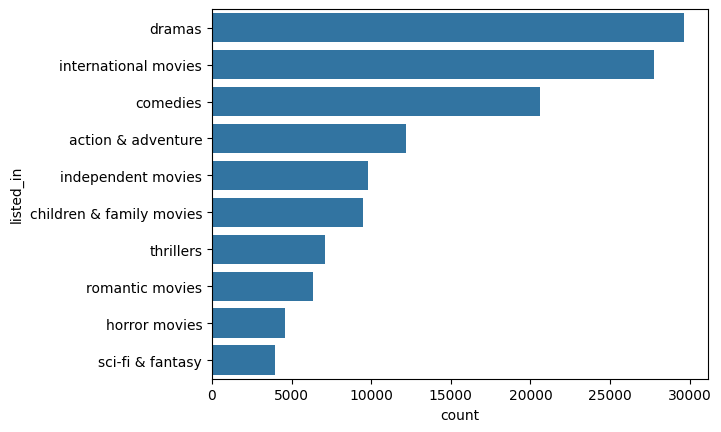

In [ ]:
sns.countplot(y='listed_in', data=df_new, order=df_new['listed_in'].value_counts().index[:10])

*Above plot shows that Dramas are listed most in netflix*

**Country wise most popular director and cast**

In [ ]:
df_new.groupby(['country', 'director'])['title'].nunique().sort_values(ascending=False)

country        director           
United States  Marcus Raboy           16
               Rajiv Chilaka          15
               Jay Karas              15
Philippines    Cathy Garcia-Molina    13
United States  Suhas Kadav            12
                                      ..
Egypt          Muhammad Ali            1
               Mohammed El-Tahawy      1
               Mohammad Adel           1
               Mohamed Yassin          1
Zimbabwe       Tomas Brickhill         1
Name: title, Length: 6552, dtype: int64

In [ ]:
df_new.groupby(['country', 'cast'])['title'].nunique().sort_values(ascending=False)

country        cast                    
India           Anupam Kher                36
               Shah Rukh Khan              25
                Paresh Rawal               24
                Om Puri                    24
United States   Rupa Bhimani               23
                                           ..
Canada          Travis Turner               1
                Trevor Tordjman             1
                Trish Stratus               1
                Tristen Marty-Pahtaykan     1
Zimbabwe       Tendaiishe Chitima           1
Name: title, Length: 44622, dtype: int64

**Director consistency**

In [ ]:
director = df_new.groupby('director').agg(min_year=('year','min'), max_year=('year','max'))
director['range'] = director['max_year'] - director['min_year']
director.sort_values('range', ascending=False).head()

,min_year,max_year,range
director,,,
David Gordon Green,2008,2020,12
Brian Levant,2008,2020,12
Steven Tsuchida,2010,2020,10
Christopher Nolan,2012,2021,9
Selçuk Metin,2012,2020,8


**Type ratio**

<Axes: xlabel='type', ylabel='count'>

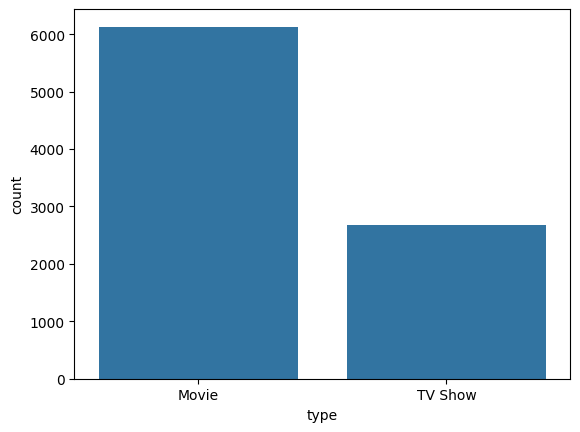

In [ ]:
sns.countplot(x='type', data=df)

In [ ]:
a = df.groupby(['type'])['type'].apply(lambda x: round(len(x) / len(df), 2))
ratio = pd.DataFrame(a).T
ratio

type,Movie,TV Show
type,0.7,0.3


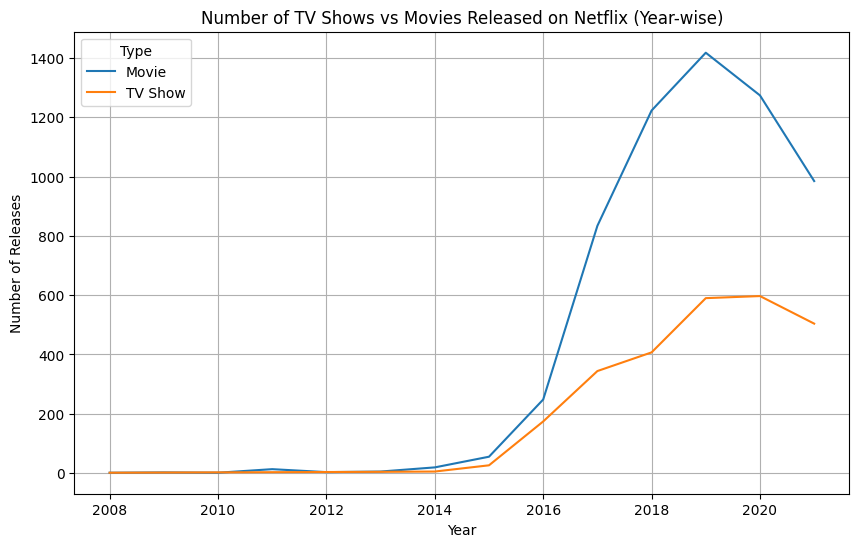

In [ ]:
yearly_content_count = df_new.groupby(['year', 'type'])['show_id'].nunique().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_content_count, x='year', y='show_id', hue='type')

plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.title('Number of TV Shows vs Movies Released on Netflix (Year-wise)')
plt.legend(title='Type')
plt.grid(True)
plt.show()

*Above plot shows that netflix focus on movies after 2016*

**Average run time of movies**

In [ ]:
data_movies = df_new.loc[df_new['type']=='Movie']
data_movies.head(5)

,show_id,type,date_added,release_year,rating,duration,description,title,director,cast,country,listed_in,year,month,day,dayofweek,dayofyear
6,s7,Movie,2021-09-24,2021,PG,91,Equestria's divided. But a bright-eyed hero be...,Ganglands,Julien Leclercq,Tracy Gotoas,United States,tv action & adventure,2021,9,24,4,3
7,s8,Movie,2021-09-24,1993,TV-MA,125,"On a photo shoot in Ghana, an American model s...",Ganglands,Julien Leclercq,Samuel Jouy,United States,crime tv shows,2021,9,24,4,3
9,s10,Movie,2021-09-24,2021,PG-13,104,A woman adjusting to life after a loss contend...,Ganglands,Julien Leclercq,Samuel Jouy,United States,tv action & adventure,2021,9,24,4,3
12,s13,Movie,2021-09-23,2021,TV-MA,127,After most of her family is murdered in a terr...,Ganglands,Julien Leclercq,Nabiha Akkari,United States,tv action & adventure,2021,9,23,3,3
13,s14,Movie,2021-09-22,2021,TV-PG,91,When the clever but socially-awkward Tetê join...,Ganglands,Julien Leclercq,Sofia Lesaffre,United States,crime tv shows,2021,9,22,2,3


In [ ]:
statistics_grouped = data_movies['duration'].groupby(data_movies['release_year']).describe()

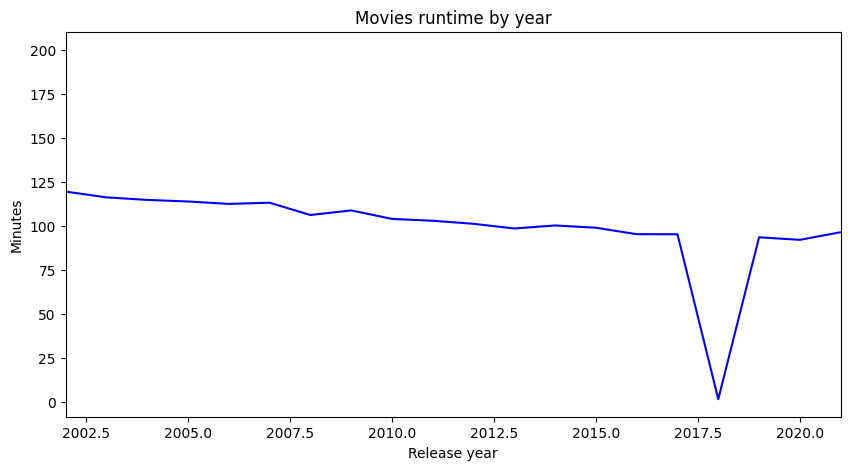

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(statistics_grouped['mean'], color="blue")
ax1.set_title('Movies runtime by year')
ax1.set_ylabel('Minutes')
ax1.set_xlabel('Release year')
ax1.set_xlim(2002, 2021)
plt.show()

*Above plot shows decrease in runtime around 2017*

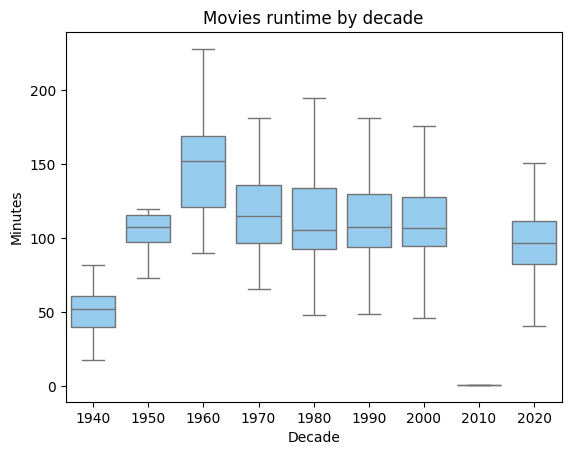

In [ ]:
movies_by_decade = data_movies.copy()
movies_by_decade['release_year'] = ((movies_by_decade['release_year'] // 10) * 10).astype('int64')
sns.boxplot(x="release_year", y="duration", data=movies_by_decade, color='lightskyblue', showfliers=False)
plt.title('Movies runtime by decade')
plt.xlabel('Decade')
plt.ylabel('Minutes')
plt.show()

*Above plot shows in decade 1960 runtime median and spread is more*

**Most popular month for uploading movies**

In [ ]:
data_movies.groupby('month')['show_id'].nunique().reset_index(name='Count').sort_values(by='Count', ascending=False).head(1)

,month,Count
6,7,558


<ipython-input-381-44d3ab65dbb2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dayofweek', y='count', data=day_of_week_analysis, palette='Blues_d')


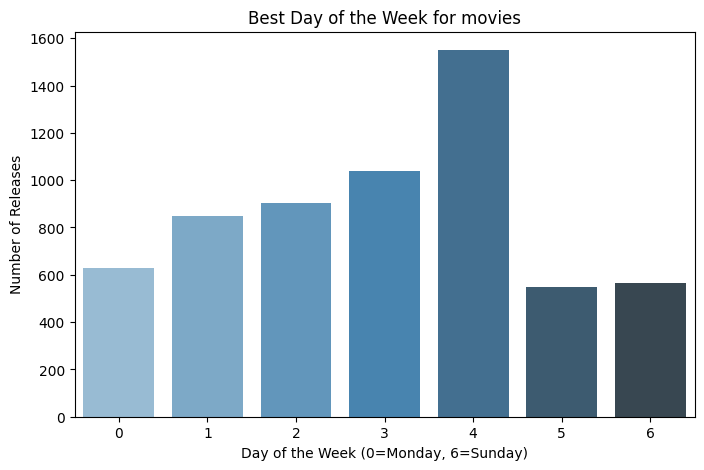

<ipython-input-381-44d3ab65dbb2>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='count', data=month_analysis, palette='Greens_d')


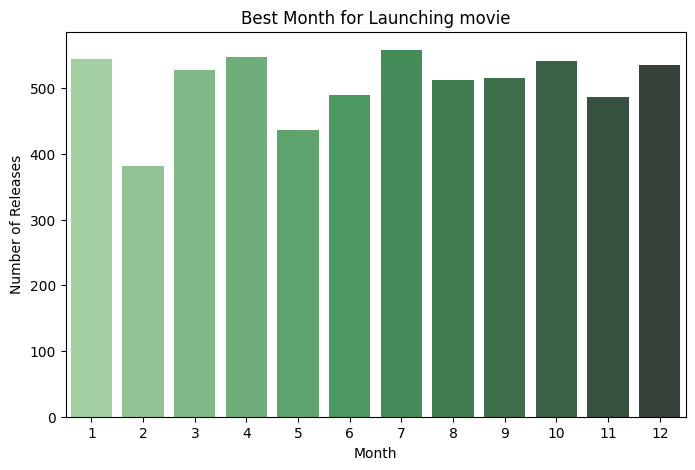

In [ ]:
day_of_week_analysis = data_movies.groupby('dayofweek')['show_id'].nunique().reset_index(name='count')
month_analysis = data_movies.groupby('month')['show_id'].nunique().reset_index(name='count')

# Day of the Week
plt.figure(figsize=(8, 5))
sns.barplot(x='dayofweek', y='count', data=day_of_week_analysis, palette='Blues_d')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Releases')
plt.title('Best Day of the Week for movies')
plt.show()

# Month
plt.figure(figsize=(8, 5))
sns.barplot(x='month', y='count', data=month_analysis, palette='Greens_d')
plt.xlabel('Month')
plt.ylabel('Number of Releases')
plt.title('Best Month for Launching movie')
plt.show()

*Above plot shows Friday and July are best day and month to launch movie*

**Year wise movie count**

In [ ]:
y_movie = data_movies.groupby('year')['title'].nunique().reset_index()
y_movie

,year,title
0,2008,1
1,2009,1
2,2010,1
3,2011,2
4,2012,3
5,2013,4
6,2014,7
7,2015,20
8,2016,62
9,2017,102


**TV Shows analysis**

In [ ]:
data_shows = df_new.loc[df_new['type']=='TV Show']
data_shows.head(5)

,show_id,type,date_added,release_year,rating,duration,description,title,director,cast,country,listed_in,year,month,day,dayofweek,dayofyear
1,s2,TV Show,2021-09-24,2021,TV-MA,2,"After crossing paths at a party, a Cape Town t...",Ganglands,Julien Leclercq,Sami Bouajila,United States,crime tv shows,2021,9,24,4,3
2,s3,TV Show,2021-09-24,2021,TV-MA,1,To protect his family from a powerful drug lor...,Ganglands,Julien Leclercq,Sami Bouajila,United States,international tv shows,2021,9,24,4,3
3,s4,TV Show,2021-09-24,2021,TV-MA,1,"Feuds, flirtations and toilet talk go down amo...",Ganglands,Julien Leclercq,Sami Bouajila,United States,tv action & adventure,2021,9,24,4,3
4,s5,TV Show,2021-09-24,2021,TV-MA,2,In a city of coaching centers known to train I...,Ganglands,Julien Leclercq,Tracy Gotoas,United States,crime tv shows,2021,9,24,4,3
5,s6,TV Show,2021-09-24,2021,TV-MA,1,The arrival of a charismatic young priest brin...,Ganglands,Julien Leclercq,Tracy Gotoas,United States,international tv shows,2021,9,24,4,3


<ipython-input-384-f48cf625766e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dayofweek', y='count', data=day_of_week_analysis, palette='Blues_d')


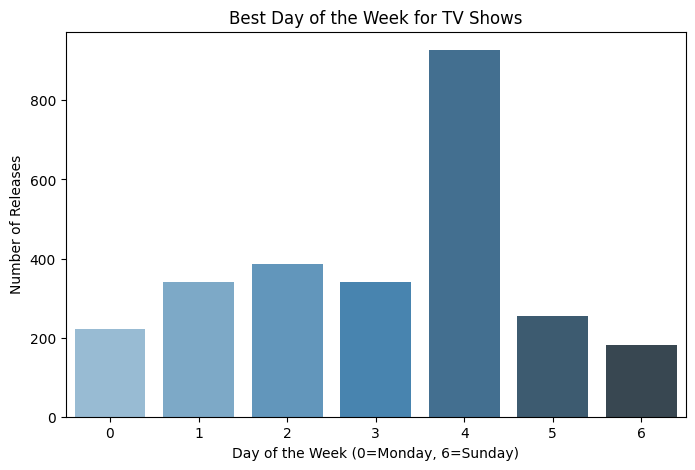

<ipython-input-384-f48cf625766e>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='count', data=month_analysis, palette='Greens_d')


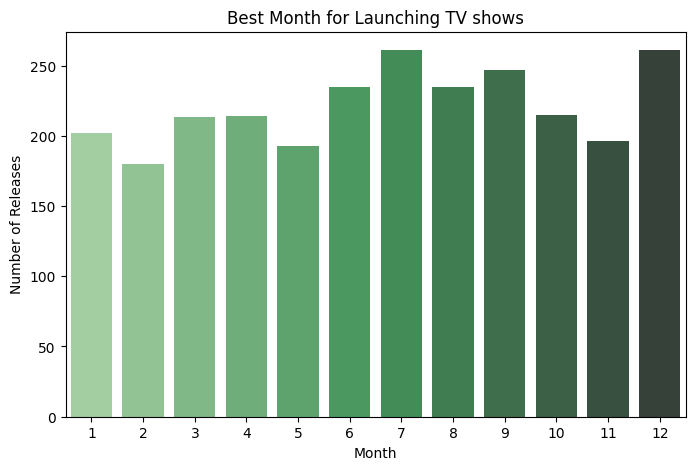

In [ ]:
day_of_week_analysis = data_shows.groupby('dayofweek')['show_id'].nunique().reset_index(name='count')
month_analysis = data_shows.groupby('month')['show_id'].nunique().reset_index(name='count')

# Day of the Week
plt.figure(figsize=(8, 5))
sns.barplot(x='dayofweek', y='count', data=day_of_week_analysis, palette='Blues_d')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Releases')
plt.title('Best Day of the Week for TV Shows')
plt.show()

# Month
plt.figure(figsize=(8, 5))
sns.barplot(x='month', y='count', data=month_analysis, palette='Greens_d')
plt.xlabel('Month')
plt.ylabel('Number of Releases')
plt.title('Best Month for Launching TV shows')
plt.show()

*Above plot shows Friday and December are best day and month to launch TV Show*

**Country and type wise analysis**

In [ ]:
country_content_count = df_new.groupby(['country', 'type'])['show_id'].nunique().sort_values(ascending=False)
country_content_count

country        type   
United States  Movie      3001
               TV Show    1217
India          Movie       577
               TV Show     337
Japan          Movie       287
                          ... 
 Senegal       Movie         1
 Serbia        Movie         1
 Singapore     Movie         1
 Slovakia      Movie         1
Zimbabwe       Movie         1
Name: show_id, Length: 225, dtype: int64

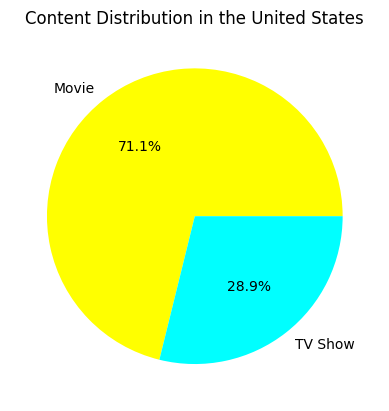

In [ ]:
us_content = country_content_count.loc['United States']
plt.pie(us_content, labels=us_content.index, autopct='%1.1f%%', colors=['yellow', 'cyan'])
plt.title('Content Distribution in the United States')
plt.show()

**Correlation between numerical data**

In [ ]:
num_df = df_new.select_dtypes(include=[float, int])
num_df.corr()

,release_year,duration,year,month,day,dayofweek,dayofyear
release_year,1.000000,-0.447471,0.305941,-0.346718,-0.203412,-0.170625,-0.335016
duration,-0.447471,1.000000,-0.439303,0.669052,0.566250,0.382962,0.636882
year,0.305941,-0.439303,1.000000,-0.553209,-0.402907,-0.314198,-0.535346
month,-0.346718,0.669052,-0.553209,1.000000,0.641627,0.433182,0.987638
day,-0.203412,0.566250,-0.402907,0.641627,1.000000,0.366369,0.602672
dayofweek,-0.170625,0.382962,-0.314198,0.433182,0.366369,1.000000,0.409663
dayofyear,-0.335016,0.636882,-0.535346,0.987638,0.602672,0.409663,1.000000


<Axes: >

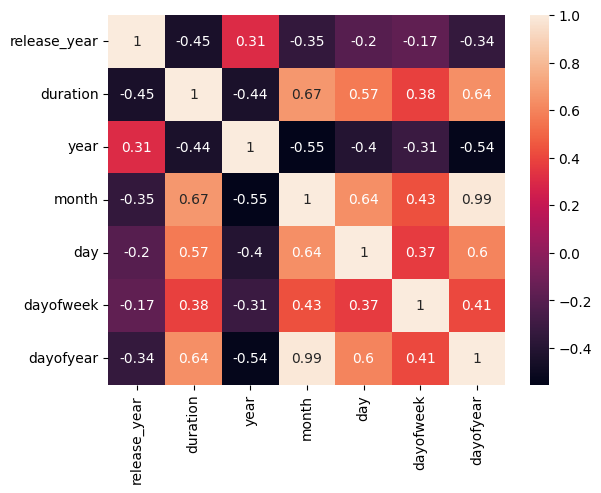

In [ ]:
sns.heatmap(num_df.corr(), annot=True)

*Above plot shows that month and year are negatively correlated and duration and month are positively correlated*

<Figure size 1000x600 with 0 Axes>

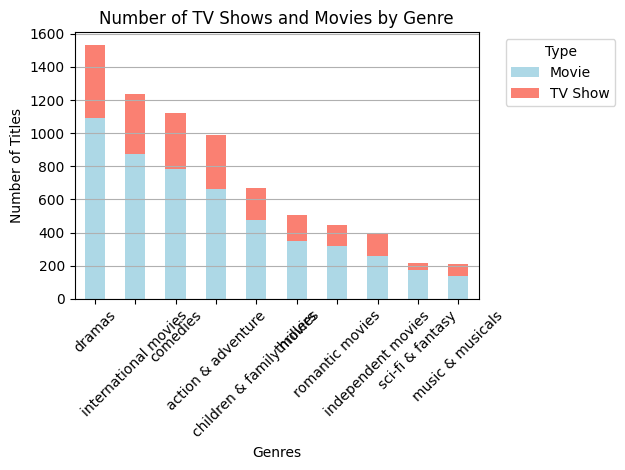

In [ ]:
genre_counts = df_new.groupby(['listed_in', 'type'])['show_id'].nunique().unstack(fill_value=0)

top_genres = genre_counts.sum(axis=1).nlargest(10).index
genre_counts = genre_counts.loc[top_genres]

plt.figure(figsize=(10, 6))
genre_counts.plot(kind='bar', stacked=True, color=['lightblue', 'salmon'])
plt.xlabel('Genres')
plt.ylabel('Number of Titles')
plt.title('Number of TV Shows and Movies by Genre')
plt.xticks(rotation=45)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()